In [13]:
# imports

import requests
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

In [14]:
# Initialization

load_dotenv(override=True)

requests.get("http://localhost:11434").content
OLLAMA_BASE_URL = "http://localhost:11434/v1"
ollama = OpenAI(base_url=OLLAMA_BASE_URL, api_key='ollama')

DB = "prices.db"

In [15]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [16]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [17]:
get_ticket_price("Paris")

DATABASE TOOL CALLED: Getting price for Paris


'Ticket price to Paris is $899.0'

In [18]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": price_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [19]:

def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = ollama.chat.completions.create(model="qwen3:14b", messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


In [20]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = ollama.chat.completions.create(model="qwen3:14b", messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = ollama.chat.completions.create(model="qwen3:14b", messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [21]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [15]:
gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7898
* To create a public link, set `share=True` in `launch()`.


In [22]:
# Some imports for handling images

import base64
from io import BytesIO
from PIL import Image

In [23]:
from diffusers import AutoPipelineForText2Image

# Load the SD Turbo pipeline once (outside the function for better performance)
pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo"
)

pipe.to("cpu")


def artist(city):
    # Create the prompt using the city name
    prompt = (
        f"An image representing a vacation in {city} "
        f"showing tourist spots and everything unique about {city} "
        f"in a vibrant pop-art style"
    )

    # Generate the image
    image = pipe(
        prompt,
        num_inference_steps=1,
        guidance_scale=0.0
    ).images[0]

    # Return the generated image
    return image





# from diffusers import DiffusionPipeline
# import torch

# import torch

# pipe = DiffusionPipeline.from_pretrained(
#     "stabilityai/stable-diffusion-xl-base-1.0",
#     torch_dtype=torch.float32
# )

# pipe.to("cpu")

# def artist(city):
#     prompt = (
#         f"An image representing a vacation in {city}, "
#         f"showing tourist spots and everything unique about {city}, "
#         f"in a vibrant pop-art style"
#     )

#     image = pipe(prompt).images[0]
#     return image

j:\Jayashree\AI_engineer_projects\.venv\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 13.05it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/p

100%|██████████| 1/1 [00:04<00:00,  5.00s/it]


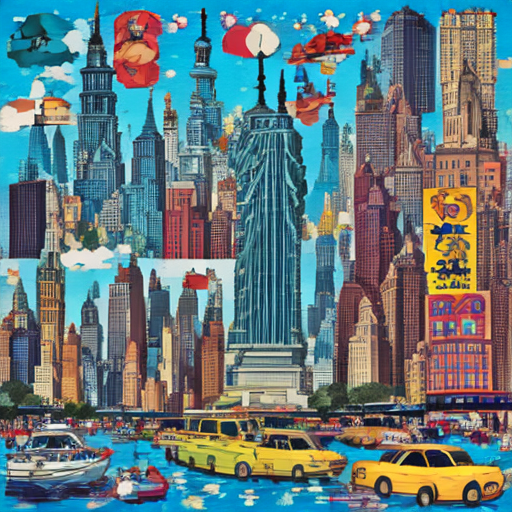

In [24]:

result = artist("New York City")
display(result)

above commented code took me than 15 hrs but still did not complete execution :

Because you're running Stable Diffusion XL (SDXL) (a very large model with approximately 6.6 billion parameters) on the CPU.

SDXL is designed for modern GPUs, not CPUs.

Why it's so slow
1. CPU is not made for AI image generation
CPUs have very little parallel processing compared to GPUs.
Image generation models perform billions of mathematical operations that GPUs are optimized for.
2. SDXL is a very large model
Model size: 6–8 GB
Components include:
UNet
VAE
CLIP
Running all of these on a CPU is extremely slow.
3. Expected CPU speed

On a normal laptop CPU:

1 image may take anywhere from 5 to 20+ hours
In some cases, it may never finish because the system starts swapping memory to disk.
4. High RAM usage

SDXL typically needs:

16–32 GB RAM when running on CPU.
If your RAM is insufficient, Windows uses virtual memory (disk swapping), which makes generation dramatically slower.
What you should do instead
Option 1: Use an NVIDIA GPU (Recommended)

Example speeds:

RTX 3060 (12 GB): 20–40 seconds per image
RTX 4060 / 4070 / 4080: Even faster
Option 2: Use Google Colab (Free GPU)

Available GPUs include:

NVIDIA T4
NVIDIA A10G (depending on availability)

This is a good option for learning and experimenting without buying hardware.

Option 3: Use a faster model for CPU

Instead of SDXL, try:

Stable Diffusion Turbo
SDXL Turbo
FLUX.1-schnell (if available)

These models are much more practical on CPUs.

Estimated time to generate one 1024×1024 image
Hardware	SDXL Base 1.0	Faster Models (SDXL Turbo / FLUX.1-schnell)
Laptop CPU	5–20+ hours	30–90 minutes
RTX 3060 (12 GB)	20–40 seconds	5–15 seconds
RTX 4060 / 4070	10–20 seconds	3–8 seconds
Google Colab (T4)	1–3 minutes	20–40 seconds
Google Colab (A10G)	30–60 seconds	10–20 seconds
Bottom line

Running Stable Diffusion XL (SDXL) on a CPU is generally not practical. If you don't have an NVIDIA GPU, consider:

Using Google Colab for free GPU access, or
Choosing a lighter model such as SDXL Turbo or FLUX.1-schnell for local experiments.

From our earlier conversation, I also noticed you're using a CPU-only PyTorch installation. If you tell me your laptop model, CPU, RAM, and whether you have an NVIDIA GPU, I can recommend the fastest open-source image model that will run well on your specific hardware.

complete executiom flow:
artist("Paris")
        │
        ▼
Create prompt
        │
        ▼
Tokenize text
        │
        ▼
CLIP Text Encoder
        │
        ▼
Text Embeddings
        │
        ▼
Random Noise
        │
        ▼
UNet (20–50 denoising steps)
        │
        ▼
Latent Image
        │
        ▼
VAE Decoder
        │
        ▼
PIL Image
        │
        ▼
Return image

In [28]:
from kokoro import KPipeline
import soundfile as sf

pipeline = KPipeline(lang_code="a")

def talker(message):
    generator = pipeline(
        message,
        voice="af_heart"
    )

    for _, _, audio in generator:
        sf.write("speech.wav", audio, 24000)

    return "speech.wav"

j:\Jayashree\AI_engineer_projects\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
j:\Jayashree\AI_engineer_projects\.venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [31]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

In [34]:
def chat(history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]

    messages = [{"role": "system", "content": system_message}] + history

    response = ollama.chat.completions.create(
        model="qwen3:14b",
        messages=messages,
        tools=tools
    )

    cities = []
    image = None

    while response.choices[0].finish_reason == "tool_calls":

        message = response.choices[0].message

        responses, cities = handle_tool_calls_and_return_cities(message)

        messages.append(message)
        messages.extend(responses)

        response = ollama.chat.completions.create(
            model="qwen3:14b",
            messages=messages,
            tools=tools
        )

    reply = response.choices[0].message.content

    history.append({
        "role": "assistant",
        "content": reply
    })

    # Open-source TTS (Kokoro)
    voice_path = talker(reply)

    # Open-source Image Generation (SDXL)
    if cities:
        image = artist(cities[0])

    return history, voice_path, image

In [ ]:
# Callbacks (along with the chat() function above)
import gradio as gr

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500)
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("jaya", "shree"))

* Running on local URL:  http://127.0.0.1:7866
* To create a public link, set `share=True` in `launch()`.


DATABASE TOOL CALLED: Getting price for London


100%|██████████| 1/1 [00:09<00:00,  9.87s/it]
